# Model Analysis - FX Pairs

This notebook reads the complete registered validation-prediction population. It compares model
families, checkpoints, fold stability, prediction agreement, and uncertainty without choosing a
model for deployment. Every exact model configuration continues to the equal-weight backtest;
validation backtest Sharpe performs selection later.

**Learning objectives**

- Audit the complete prediction population by label, family, configuration, and checkpoint.
- Compare predictive diagnostics without using them as selection criteria.
- Evaluate stability and chronological conformal coverage from canonical prediction artifacts.
- Keep causal estimates separate from predictive-family evidence.

**Book reference**: Chapters 11-15

**Prerequisites**: `06_linear`, `07_gbm`, `08_tabular_dl`, `09_dl_tcn`,
`10_dl_nlinear`, and `11_causal_dml`.

In [1]:
"""Analyze the complete FX validation-prediction population."""

import plotly.express as px
import polars as pl
import yaml
from IPython.display import display
from ml4t.diagnostic.metrics import cross_sectional_ic

import utils.style  # noqa: F401
from case_studies.research import CausalResult, Result, open_study, superseded_members
from case_studies.research.results import PredictionResult
from case_studies.utils.conformal import (
    sizing_conformal_lag,
    walk_forward_conformal_coverage,
)
from utils.modeling import load_configs
from utils.paths import get_case_study_dir

In [2]:
CASE_STUDY = "fx_pairs"
N_BUCKETS = 5
# This notebook reads; it fits nothing and registers nothing, so it has no preview form - a
# preview population is not the thing whose assembly it checks. It still takes the pair,
# because WORKSPACE is what lets a run read an isolated registry instead of the published one.
# Study.open(CASE_STUDY) resolved through the repo case directory, which holds a registry only
# where a maintainer worktree has linked one there; anywhere else it read nothing at all.
EXECUTION_TIER = "canonical"
WORKSPACE: str | None = None

## Load the canonical population

A downstream-selectable row must use the current identity schema, carry exact coverage and fold
metrics, and have its prediction artifact available. Causal DML is deliberately absent because it
estimates a treatment effect rather than a cross-sectional score.

In [3]:
case_dir = get_case_study_dir(CASE_STUDY)
setup = yaml.safe_load((case_dir / "config" / "setup.yaml").read_text())
primary_label = setup["labels"]["primary"]
configured_labels = [primary_label, *setup["labels"].get("variants", [])]
study = open_study(CASE_STUDY, execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)
catalog = study.predictions.table().filter(
    (pl.col("identity_status") == "current")
    & (pl.col("execution_tier") == "canonical")
    & (pl.col("split") == "validation")
)
# `identity_status` names the schema version a row was written under. It says nothing about
# which generation the row's producer still publishes: a model notebook that refits leaves the
# generation it replaced in the registry, complete and current under that column, so the filter
# above carries retired prediction sets into the analysis. The lineage is what answers it, and
# `superseded_members` reads that - the same exclusion `13_backtest` applies before it freezes
# the baseline population, so the analysed catalog and the backtested one describe one set of
# models rather than two.
retired = superseded_members(study, member_kind="prediction")
if retired:
    catalog = catalog.filter(~pl.col("prediction_hash").is_in(list(retired)))

if catalog.is_empty():
    raise RuntimeError("no current canonical validation predictions are registered")
if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("model analysis requires complete prediction sets")
if catalog.filter(~pl.col("artifact_available")).height:
    raise RuntimeError("model analysis requires every prediction artifact")
if "causal_dml" in set(catalog.get_column("family")):
    raise RuntimeError("causal DML must not enter the predictive catalog")

identity_columns = [
    "label",
    "family",
    "config_name",
    "checkpoint_kind",
    "checkpoint_value",
    "training_hash",
    "prediction_hash",
]
if catalog.select(identity_columns).n_unique() != catalog.height:
    raise RuntimeError("prediction rows do not retain one complete model identity")

## Compare the assembled population against the configured menu

Each notebook checks that it produced what it requested. Nothing checks that the requests covered
what the case study configures, and a population that is internally consistent but short a
configured model reads exactly like a complete one. This compares the assembled population to the
menu itself.

`deep_learning` is the one family split across several notebooks - `09_dl_tcn`,
`10_dl_nlinear` and `10a_dl_lstm` - so a configured architecture outside that set would have
no notebook to produce it. Such members are excluded by name and reason rather than passing
unnoticed, and the exclusions are derived from the menu per label rather than listed, so a
label that never declares a member does not gain a phantom exclusion for it. The set is empty
today: `lstm_h64` was the one configured architecture nothing fitted, and `10a_dl_lstm` closed
it. The derivation stays because a menu that grows again should say so here rather than
silently publish a population short of what it declares.

In [4]:
SEQUENCE_NOTEBOOK_ARCHITECTURES = {"tcn", "nlinear", "lstm_h64"}
EXCLUSION_REASON = "configured but no scoped fx_pairs notebook runs it; coverage decision open"

configured_members = {
    (label, family, config["config_name"])
    for label in configured_labels
    for family in ("linear", "gbm", "tabular_dl", "deep_learning")
    for config in load_configs(CASE_STUDY, label, family=family)
}
excluded_members = {
    (label, family, config_name)
    for label, family, config_name in configured_members
    if family == "deep_learning" and config_name not in SEQUENCE_NOTEBOOK_ARCHITECTURES
}
expected_members = configured_members - excluded_members
present_members = set(catalog.select("label", "family", "config_name").unique().iter_rows())

if excluded_members:
    print(f"Declared exclusions ({EXCLUSION_REASON}):")
    for member in sorted(excluded_members):
        print(f"  {member[0]} / {member[1]} / {member[2]}")

missing_members = sorted(expected_members - present_members)
unexpected_members = sorted(present_members - expected_members)
if missing_members or unexpected_members:
    raise RuntimeError(
        "the assembled population does not match the configured menu; "
        f"missing {missing_members}, unexpected {unexpected_members}"
    )
if set(catalog.get_column("label")) != set(configured_labels):
    raise RuntimeError("the canonical prediction population does not cover every configured label")

In [5]:
population_summary = (
    catalog.group_by("label", "family")
    .agg(
        pl.col("config_name").n_unique().alias("configurations"),
        pl.len().alias("checkpoints"),
        pl.col("complete").all().alias("complete"),
        pl.col("ic_mean").is_not_null().sum().alias("diagnosed_checkpoints"),
    )
    .sort("label", "family")
)
population_summary

label,family,configurations,checkpoints,complete,diagnosed_checkpoints
str,str,u32,u32,bool,u32
"""fwd_ret_1d""","""deep_learning""",3,60,true,60
"""fwd_ret_1d""","""gbm""",15,150,true,150
"""fwd_ret_1d""","""linear""",28,28,true,28
"""fwd_ret_1d""","""tabular_dl""",3,24,true,24
"""fwd_ret_21d""","""deep_learning""",3,60,true,60
…,…,…,…,…,…
"""fwd_ret_21d""","""tabular_dl""",3,24,true,24
"""fwd_ret_5d""","""deep_learning""",3,60,true,60
"""fwd_ret_5d""","""gbm""",15,150,true,150


## Compare predictive diagnostics

Rank correlation is computed across pairs at each decision date and then averaged through time.
The rows shown below are descriptive representatives for plots. They do not filter the official
prediction population and do not choose checkpoints for backtesting.

In [6]:
diagnosed = catalog.filter(pl.col("ic_mean").is_not_null())
representatives = (
    diagnosed.sort(
        ["label", "family", "ic_mean", "config_name", "checkpoint_value", "prediction_hash"],
        descending=[False, False, True, False, False, False],
        nulls_last=True,
    )
    .group_by("label", "family", maintain_order=True)
    .first()
    .sort("label", "family")
)
representatives.select(
    "label",
    "family",
    "config_name",
    "checkpoint_kind",
    "checkpoint_value",
    "ic_mean",
    "ic_t",
    "prediction_hash",
)

label,family,config_name,checkpoint_kind,checkpoint_value,ic_mean,ic_t,prediction_hash
str,str,str,str,i64,f64,f64,str
"""fwd_ret_1d""","""deep_learning""","""tcn""","""epoch""",10,0.01495,2.052329,"""0eb73fea6afa"""
"""fwd_ret_1d""","""gbm""","""default_mae""","""iteration""",50,0.003515,0.468365,"""9cbace3da9d1"""
"""fwd_ret_1d""","""linear""","""enet_f0.2""","""final""",null,0.002989,0.232337,"""54626bec011c"""
"""fwd_ret_1d""","""tabular_dl""","""tabm_s""","""epoch""",50,0.005539,0.727288,"""ecf5298efdb7"""
"""fwd_ret_21d""","""deep_learning""","""tcn""","""epoch""",5,0.034523,1.102074,"""a66b3e8773ed"""
…,…,…,…,…,…,…,…
"""fwd_ret_21d""","""tabular_dl""","""tabm_s""","""epoch""",50,0.012781,0.362252,"""083cd658ee85"""
"""fwd_ret_5d""","""deep_learning""","""tcn""","""epoch""",15,0.022848,2.859644,"""95854494a6ac"""
"""fwd_ret_5d""","""gbm""","""default_mse""","""iteration""",300,0.006738,0.536078,"""c922c674362c"""


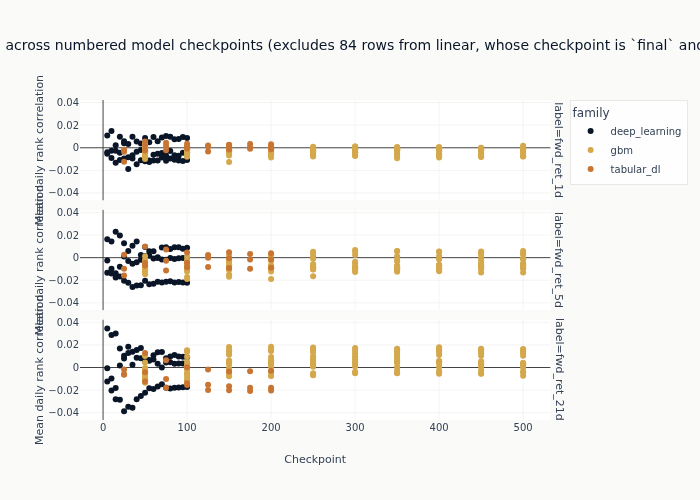

In [7]:
# Families whose checkpoint is `final` carry no numeric checkpoint position, so they have no x
# coordinate on this axis and plotly would drop them without saying so. They are excluded here by
# name rather than silently, and the count is stated in the title.
numbered = diagnosed.filter(pl.col("checkpoint_value").is_not_null())
unnumbered = diagnosed.filter(pl.col("checkpoint_value").is_null())
excluded_families = sorted(set(unnumbered.get_column("family"))) if unnumbered.height else []
figure = px.scatter(
    numbered,
    x="checkpoint_value",
    y="ic_mean",
    color="family",
    facet_row="label",
    hover_data=["config_name", "prediction_hash"],
    title=(
        "Validation rank correlation across numbered model checkpoints"
        + (
            f" (excludes {unnumbered.height} rows from {', '.join(excluded_families)},"
            " whose checkpoint is `final` and has no numeric position)"
            if excluded_families
            else ""
        )
    ),
    labels={"checkpoint_value": "Checkpoint", "ic_mean": "Mean daily rank correlation"},
)
figure.show()

## Load canonical prediction columns

Producers use `symbol`, `timestamp`, `fold`, `prediction`, and `actual`. Adding the full catalog
identity to each frame keeps two checkpoints from collapsing into one plot label or fold count.

In [8]:
prediction_frames = []
for row in representatives.iter_rows(named=True):
    result = Result.open(study, row["prediction_hash"])
    if not isinstance(result, PredictionResult):
        raise TypeError(f"{row['prediction_hash']} is not a prediction result")
    frame = result.load()
    required = {"symbol", "timestamp", "fold", "prediction", "actual"}
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f"prediction {result.hash} lacks canonical columns: {sorted(missing)}")
    if frame.select("symbol", "timestamp", "fold").n_unique() != frame.height:
        raise ValueError(f"prediction {result.hash} has duplicate eligible keys")
    prediction_frames.append(
        frame.with_columns(
            pl.lit(row["label"]).alias("label"),
            pl.lit(row["family"]).alias("family"),
            pl.lit(row["config_name"]).alias("config_name"),
            pl.lit(row["checkpoint_value"]).alias("checkpoint_value"),
            pl.lit(row["prediction_hash"]).alias("prediction_hash"),
        )
    )

representative_predictions = pl.concat(prediction_frames, how="diagonal_relaxed")

## Fold stability

Fold identifiers are labels, not dates. The table orders validation windows by their earliest
timestamp and retains checkpoint identity in every row.

**What the spread across folds is telling you.** An average IC computed over five validation
windows can be produced two ways that mean opposite things. A configuration that scores a
similar small positive number in every window has found something that persisted across five
different market regimes. A configuration that scores strongly in one window and around zero or
negative in the rest can reach the same average, and what it has found is one period.

The second is the more common outcome and the easier one to mistake for the first, because the
summary row is identical. It is also the one a walk-forward protocol is specifically designed to
expose: each window is fitted on its own past, so a configuration that only works when a
particular regime is in the training data reveals itself as soon as a window arrives where it
is not.

For currencies this matters more than it would elsewhere, because the regimes are long. Carry
and momentum in FX go through multi-year stretches of working and multi-year stretches of not,
and five validation windows drawn from a single decade can easily contain only one turn between
them. A configuration that is stable across these five folds has cleared a lower bar than the
phrase suggests, and one that is not stable across them has failed a very low one.

In [9]:
fold_rows = []
for keys, frame in representative_predictions.group_by(
    "label", "family", "config_name", "checkpoint_value", "prediction_hash", "fold"
):
    stats = cross_sectional_ic(
        frame.select("symbol", "timestamp", "prediction"),
        frame.select("symbol", "timestamp", "actual"),
        pred_col="prediction",
        ret_col="actual",
        date_col="timestamp",
        entity_col="symbol",
        min_obs=5,
    )
    fold_rows.append(
        {
            "label": keys[0],
            "family": keys[1],
            "config_name": keys[2],
            "checkpoint_value": keys[3],
            "prediction_hash": keys[4],
            "fold": keys[5],
            "validation_start": frame.get_column("timestamp").min(),
            "ic_mean": stats["ic_mean"],
            "n_decision_times": stats["n_periods"],
        }
    )
fold_metrics = pl.DataFrame(fold_rows).sort("label", "validation_start", "family")
fold_metrics

label,family,config_name,checkpoint_value,prediction_hash,fold,validation_start,ic_mean,n_decision_times
str,str,str,i64,str,i64,"datetime[μs, UTC]",f64,i64
"""fwd_ret_1d""","""deep_learning""","""tcn""",10,"""0eb73fea6afa""",0,2016-01-05 00:00:00 UTC,0.005106,258
"""fwd_ret_1d""","""gbm""","""default_mae""",50,"""9cbace3da9d1""",0,2016-01-05 00:00:00 UTC,0.00027,258
"""fwd_ret_1d""","""linear""","""enet_f0.2""",null,"""54626bec011c""",0,2016-01-05 00:00:00 UTC,0.015865,258
"""fwd_ret_1d""","""tabular_dl""","""tabm_s""",50,"""ecf5298efdb7""",0,2016-01-05 00:00:00 UTC,0.035706,258
"""fwd_ret_1d""","""deep_learning""","""tcn""",10,"""0eb73fea6afa""",1,2017-01-04 00:00:00 UTC,0.045987,258
…,…,…,…,…,…,…,…,…
"""fwd_ret_5d""","""tabular_dl""","""tabm_l""",50,"""7db90b5518e1""",6,2022-01-03 00:00:00 UTC,-0.035163,258
"""fwd_ret_5d""","""deep_learning""","""tcn""",15,"""95854494a6ac""",7,2023-01-03 00:00:00 UTC,0.008208,253
"""fwd_ret_5d""","""gbm""","""default_mse""",300,"""c922c674362c""",7,2023-01-03 00:00:00 UTC,-0.01987,253


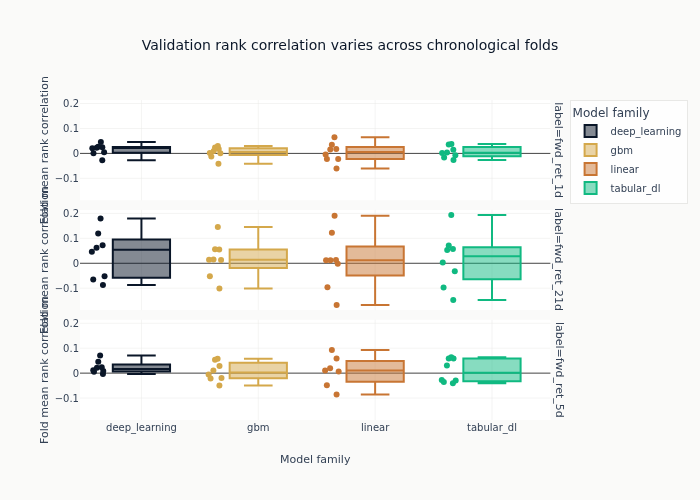

In [10]:
fold_figure = px.box(
    fold_metrics,
    x="family",
    y="ic_mean",
    color="family",
    facet_row="label",
    points="all",
    title="Validation rank correlation varies across chronological folds",
    labels={"family": "Model family", "ic_mean": "Fold mean rank correlation"},
)
fold_figure.show()

## Prediction agreement and ranking shape

Correlation between model scores shows whether families rank pairs similarly. One correlation
matrix covers one label: scores fitted against different targets are not comparable ranks of the
same quantity, so the pivot takes the primary label the menu declares rather than all three.
Return buckets and conformal coverage carry no such restriction and run over every label.

**Why ask whether the families agree.** The sweep fits a linear model, gradient boosting, and
three sequence architectures, and the implicit promise of doing that is that they bring
different views of the same data. This is where that promise is checked rather than assumed.

If the score correlations come back near one, the families are reproducing each other's
rankings and the breadth of the sweep is nominal: the effective number of independent attempts
is far smaller than the row count, whichever one wins the backtest wins by a margin that is
mostly noise, and there is nothing for an ensemble to average away. If they come back low or
mixed, the families are disagreeing about which pairs to hold, and the choice between them is a
real one with real consequences for the backtest.

It also bears on how the eventual winner should be read. Selecting the best of five
near-identical configurations is close to selecting at random among them, and the deflated
Sharpe machinery downstream exists precisely because the number of things tried inflates the
best result. That correction divides by a count of trials, and this section is where a reader
can see whether that count is measuring independent attempts or the same attempt five times.

In [11]:
primary = representative_predictions.filter(pl.col("label") == primary_label)
print(f"Score agreement is computed on {primary_label}, the primary label in the menu")
# The pivot index is the canonical eligibility key alone. `actual` is the same realized return for
# every model at a given key, but the families do not agree on its float representation, so including
# it split the rows into disjoint groups - each score column populated on a different half - and every
# correlation, including the diagonal, came out NaN.
wide = primary.pivot(
    on="prediction_hash",
    index=["symbol", "timestamp", "fold"],
    values="prediction",
)
prediction_columns = [
    column for column in wide.columns if column not in {"symbol", "timestamp", "fold"}
]
if wide.height != primary.height // primary.get_column("prediction_hash").n_unique():
    raise RuntimeError("the agreement pivot did not align every representative on the same keys")
if any(wide.get_column(column).null_count() for column in prediction_columns):
    raise RuntimeError("a representative is missing scores at keys the others cover")
agreement = wide.select(prediction_columns).corr()
agreement

Score agreement is computed on fwd_ret_1d, the primary label in the menu


0eb73fea6afa,9cbace3da9d1,54626bec011c,ecf5298efdb7
f64,f64,f64,f64
1.0,0.11748,0.048416,-0.088493
0.11748,1.0,0.418956,0.207571
0.048416,0.418956,1.0,0.232102
-0.088493,0.207571,0.232102,1.0


In [12]:
bucket_rows = []
for keys, frame in representative_predictions.group_by(
    "label", "family", "config_name", "checkpoint_value", "prediction_hash", "timestamp"
):
    if frame.height < N_BUCKETS:
        continue
    ranked = frame.sort("prediction").with_columns(
        ((pl.int_range(pl.len()) * N_BUCKETS) // pl.len())
        .clip(upper_bound=N_BUCKETS - 1)
        .alias("bucket")
    )
    for bucket, values in ranked.group_by("bucket"):
        bucket_rows.append(
            {
                "label": keys[0],
                "family": keys[1],
                "config_name": keys[2],
                "checkpoint_value": keys[3],
                "prediction_hash": keys[4],
                "timestamp": keys[5],
                "bucket": bucket[0],
                "actual": values.get_column("actual").mean(),
            }
        )
bucket_summary = (
    pl.DataFrame(bucket_rows)
    .group_by("label", "family", "config_name", "checkpoint_value", "prediction_hash", "bucket")
    .agg(pl.col("actual").mean().alias("mean_realized_return"))
    .sort("label", "family", "bucket")
)
# Three labels sort as 1d, 21d, 5d, so the default row window hides the middle one entirely and
# a reader would see the same two-thirds coverage this section exists to remove.
with pl.Config(tbl_rows=bucket_summary.height):
    display(bucket_summary)

label,family,config_name,checkpoint_value,prediction_hash,bucket,mean_realized_return
str,str,str,i64,str,i64,f64
"""fwd_ret_1d""","""deep_learning""","""tcn""",10,"""0eb73fea6afa""",0,-0.000083
"""fwd_ret_1d""","""deep_learning""","""tcn""",10,"""0eb73fea6afa""",1,-0.000074
"""fwd_ret_1d""","""deep_learning""","""tcn""",10,"""0eb73fea6afa""",2,0.000138
"""fwd_ret_1d""","""deep_learning""","""tcn""",10,"""0eb73fea6afa""",3,0.000101
"""fwd_ret_1d""","""deep_learning""","""tcn""",10,"""0eb73fea6afa""",4,0.000045
"""fwd_ret_1d""","""gbm""","""default_mae""",50,"""9cbace3da9d1""",0,0.000076
"""fwd_ret_1d""","""gbm""","""default_mae""",50,"""9cbace3da9d1""",1,-0.000058
"""fwd_ret_1d""","""gbm""","""default_mae""",50,"""9cbace3da9d1""",2,0.00003
"""fwd_ret_1d""","""gbm""","""default_mae""",50,"""9cbace3da9d1""",3,-0.000017


## Coverage of the widths that size positions

**What a conformal width is, and why a portfolio wants one.** A point prediction says where a
return is likely to land and says nothing about how confident that is. Two pairs can carry the
same predicted return with entirely different dispersion around it, and a portfolio that sizes
both the same is taking more risk in one than in the other without having decided to.

Split conformal produces the missing quantity without assuming a distribution. Residuals from
data the model was not fitted on are collected, and the width is a quantile of their absolute
values: the interval is as wide as the model has recently been wrong. Nothing is assumed to be
Gaussian and nothing is estimated from the evaluation window.

The allocator downstream does not use it as an interval at all. It reads the width as a
per-symbol volatility estimate and sizes inversely to it, so a pair the model has lately been
wrong about gets a smaller position. That is why coverage is checked here even though no
decision reads a coverage level: the width is only a sensible risk proxy if it tracks the
dispersion it claims to, and a width that systematically under-covers is a position size that
is systematically too large.

The width reported here is the one `conformal_weighted` allocates with: calibrated per symbol on
every residual known at `t - h`, where `h` is the label's horizon in data steps, with a pooled
quantile where a symbol has too few of its own. A decision is covered when its absolute residual
falls inside that half-width.

Read it as a diagnostic of residual dispersion, not as a guarantee. Split conformal's
finite-sample coverage needs the calibration and evaluation residuals to be exchangeable, and
currency returns are heteroskedastic and regime-dependent. Nothing in the allocation path reads
an interval or a coverage level - the width stands in for a volatility estimate, and `n_test`
counts the decisions a width could be calibrated for.

In [13]:
conformal_rows = []
for keys, frame in representative_predictions.group_by(
    "label", "family", "config_name", "checkpoint_value", "prediction_hash"
):
    embargo_steps = sizing_conformal_lag("fx_pairs", keys[0])
    for row in walk_forward_conformal_coverage(frame, embargo_steps=embargo_steps):
        conformal_rows.append(
            {
                "label": keys[0],
                "family": keys[1],
                "config_name": keys[2],
                "checkpoint_value": keys[3],
                "prediction_hash": keys[4],
                **row,
            }
        )
conformal = pl.DataFrame(conformal_rows).sort("label", "nominal_level", "family")
with pl.Config(tbl_rows=conformal.height, tbl_cols=conformal.width, tbl_width_chars=200):
    display(conformal)

case_studies/utils/conformal.py:515: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  targets.join_asof(


label,family,config_name,checkpoint_value,prediction_hash,nominal_level,empirical_coverage,mean_interval_width_frac_std,n_test,n_uncalibrated
str,str,str,i64,str,f64,f64,f64,i64,i64
"""fwd_ret_1d""","""deep_learning""","""tcn""",10,"""0eb73fea6afa""",0.8,0.783503,17.083606,41220,40
"""fwd_ret_1d""","""gbm""","""default_mae""",50,"""9cbace3da9d1""",0.8,0.828651,2.479071,41220,40
"""fwd_ret_1d""","""linear""","""enet_f0.2""",null,"""54626bec011c""",0.8,0.827462,2.462103,41220,40
"""fwd_ret_1d""","""tabular_dl""","""tabm_s""",50,"""ecf5298efdb7""",0.8,0.824915,2.507869,41220,40
"""fwd_ret_1d""","""deep_learning""","""tcn""",10,"""0eb73fea6afa""",0.9,0.882242,22.363366,41220,40
"""fwd_ret_1d""","""gbm""","""default_mae""",50,"""9cbace3da9d1""",0.9,0.917516,3.346947,41220,40
"""fwd_ret_1d""","""linear""","""enet_f0.2""",null,"""54626bec011c""",0.9,0.917637,3.325576,41220,40
"""fwd_ret_1d""","""tabular_dl""","""tabm_s""",50,"""ecf5298efdb7""",0.9,0.916473,3.377379,41220,40
"""fwd_ret_1d""","""deep_learning""","""tcn""",10,"""0eb73fea6afa""",0.95,0.932824,26.995533,41220,40


## Causal evidence remains separate

A causal result answers whether the configured momentum treatment has an estimated effect after
adjustment for its declared confounders. It does not count as predictive-family coverage and does
not enter the model or backtest population. `11_causal_dml` registers one estimate per label the
menu declares, so naming a single label here would leave the rest of them unreported.

In [14]:
causal_rows = []
for label in configured_labels:
    causal = CausalResult.one(study, label=label)
    causal_rows.append({"label": label, "causal_hash": causal.hash, **causal.metrics})
causal_summary = (
    pl.DataFrame(causal_rows)
    .select(
        "label",
        "causal_hash",
        "n_obs",
        "dml_effect",
        "dml_se_hac",
        "p_value_hac",
        "naive_effect",
        "confounding_bias_pct",
        "refutation_p",
    )
    .sort("label")
)
causal_summary

label,causal_hash,n_obs,dml_effect,dml_se_hac,p_value_hac,naive_effect,confounding_bias_pct,refutation_p
str,str,i64,f64,f64,f64,f64,f64,f64
"""fwd_ret_1d""","""41a7a56a0118""",49600,-0.000057,0.000721,0.936836,-0.000203,-254.954828,0.940594
"""fwd_ret_21d""","""84fb196c27f6""",48880,0.004423,0.011013,0.687978,-0.001638,-137.028185,0.821782
"""fwd_ret_5d""","""01fc2d8159c1""",49460,0.000971,0.003339,0.771146,-0.000236,-124.295326,0.841584


## Handoff to the equal-weight backtest

Every complete catalog row, including every checkpoint, advances to `13_backtest`. The backtest
receives these rows directly and records one result per row. Neither this notebook's descriptive
representatives nor any IC or causal statistic changes that population.

In [15]:
handoff = catalog.select([*identity_columns, "cv_identity", "complete"]).sort(
    "label", "family", "config_name", "checkpoint_value"
)
handoff

label,family,config_name,checkpoint_kind,checkpoint_value,training_hash,prediction_hash,cv_identity,complete
str,str,str,str,i64,str,str,str,bool
"""fwd_ret_1d""","""deep_learning""","""lstm_h64""","""epoch""",5,"""225e9d237512""","""ea8b69c86459""","""b8c41a40b6f5fd13""",true
"""fwd_ret_1d""","""deep_learning""","""lstm_h64""","""epoch""",10,"""225e9d237512""","""486d60df8cd3""","""b8c41a40b6f5fd13""",true
"""fwd_ret_1d""","""deep_learning""","""lstm_h64""","""epoch""",15,"""225e9d237512""","""62d3fed33dbf""","""b8c41a40b6f5fd13""",true
"""fwd_ret_1d""","""deep_learning""","""lstm_h64""","""epoch""",20,"""225e9d237512""","""2cdd3be1dab2""","""b8c41a40b6f5fd13""",true
"""fwd_ret_1d""","""deep_learning""","""lstm_h64""","""epoch""",25,"""225e9d237512""","""413eae56da50""","""b8c41a40b6f5fd13""",true
…,…,…,…,…,…,…,…,…
"""fwd_ret_5d""","""tabular_dl""","""tabm_s""","""epoch""",100,"""f76f074735d9""","""dda1dee210b1""","""f1980839a30d30a1""",true
"""fwd_ret_5d""","""tabular_dl""","""tabm_s""","""epoch""",125,"""f76f074735d9""","""84fc0eb094b2""","""f1980839a30d30a1""",true
"""fwd_ret_5d""","""tabular_dl""","""tabm_s""","""epoch""",150,"""f76f074735d9""","""15a0cbdeb7f8""","""f1980839a30d30a1""",true


## Key takeaways

- Model identity includes label, family, configuration, checkpoint, and validation protocol.
- Daily rank correlation, fold stability, bucket shape, and conformal coverage are diagnostics.
- The equal-weight validation backtest receives the complete prediction population.
- Causal estimates remain a separate form of evidence.